Nodes: torch.Size([1140, 8]) | Edges: torch.Size([2, 4522]) | Edge Features: torch.Size([4522, 4]) | Join Pairs: torch.Size([0])
w_phys: 20.0
w_smooth: 0.5
w_mass: 2.0
w_collision: 2.0
w_continuity: 1.0
w_shape: 0.5
w_keepout: 1.0
Epoch ||  Loss  ||  Phys  |  Smth  | Area(cu/tg) |  Mass  |  Coll  |  Cont  | Shape  | Keepout
00099 || 48.5172 || 2.4251 | 0.1510 | 1248 /    0 | 0.0012 | 0.0000 | 0.0160 | 8.3275 | 0.0000
  [GHOST] sec0-p0(t=0.01), sec0-p2(t=0.01), sec1-p0(t=0.01), sec1-p2(t=0.01), sec2-p0(t=0.01), sec2-p2(t=0.01), sec3-p0(t=0.01), sec3-p2(t=0.01), sec4-p0(t=0.01), sec4-p2(t=0.01), sec5-p0(t=0.01), sec5-p2(t=0.01), sec6-p0(t=0.01), sec6-p2(t=0.01), sec7-p0(t=0.01), sec7-p2(t=0.01), sec8-p0(t=0.01), sec8-p2(t=0.01), sec8-p3(t=0.01), sec9-p0(t=0.01), sec9-p2(t=0.01), sec9-p3(t=0.01), sec10-p0(t=0.01), sec10-p2(t=0.01), sec10-p3(t=0.01), sec11-p0(t=0.01), sec11-p2(t=0.01), sec11-p3(t=0.01), sec12-p0(t=0.01), sec12-p2(t=0.01), sec12-p3(t=0.01), sec13-p0(t=0.01), sec13-p2(t=0.01

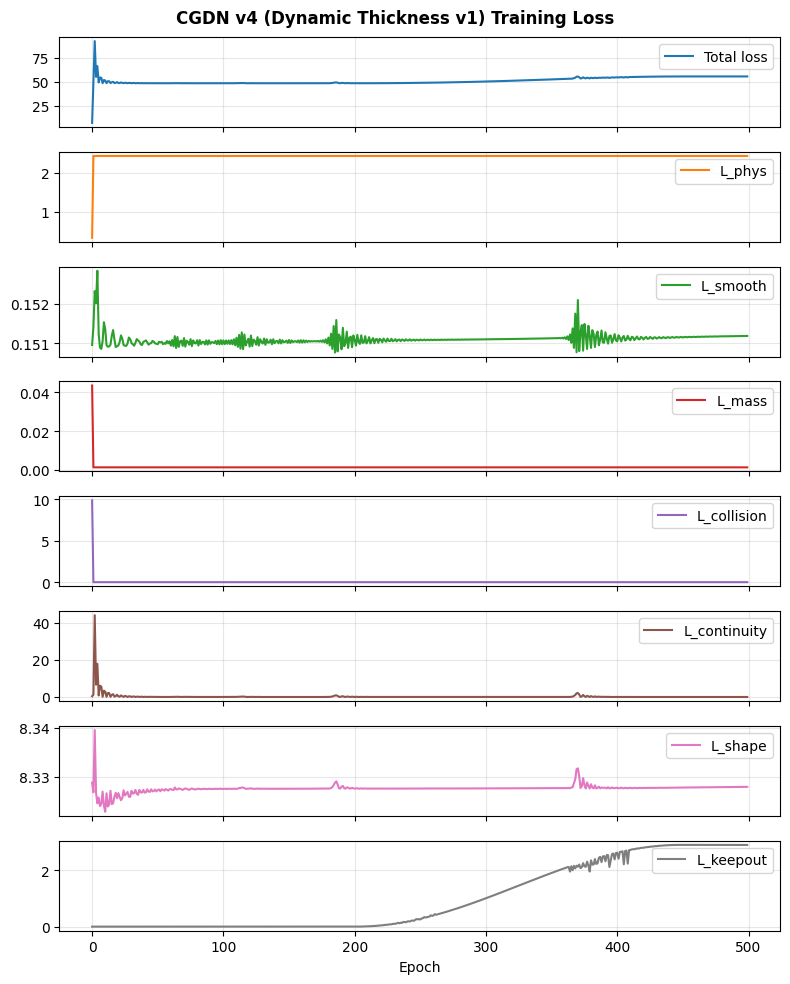

Final Mp (N·mm) | Dynamic Thickness v4 (v1 patch)
  Section  |    initial |  predicted |     target |  % error |  avg_t |  alpha
───────────────────────────────────────────────────────────────────────────
  Section 16  |   55645928 |     186636 |   55645928 |   99.66% |  0.005 |  0.000 [GHOST]
  Section 15  |   58332280 |     195854 |   58000000 |   99.66% |  0.005 |  0.000 [GHOST]
  Section 14  |   48815580 |     163921 |   47000000 |   99.65% |  0.005 |  0.000 [GHOST]
  Section 13  |   51027908 |     171359 |   52000000 |   99.67% |  0.005 |  0.000 [GHOST]
  Section 12  |   53250532 |     178839 |   57000000 |   99.69% |  0.005 |  0.000 [GHOST]
  Section 11  |   73839688 |    2709014 |   75000000 |   96.39% |  0.073 |  0.125
  Section 10  |   76774264 |    2811974 |   77000000 |   96.35% |  0.073 |  0.125
  Section  9  |   79720632 |    2915183 |   79000000 |   96.31% |  0.073 |  0.125
  Section  8  |   82677968 |    3019348 |   81000000 |   96.27% |  0.073 |  0.125
  Section  7  |  

In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:

# AI_design_v1.py — Dynamic Thickness CGDN v4 (Improved)
# Base: AI_design_v0.py
# Applied: dynamic_thickness_v3.md (Trivial Solution 방지 패치)
#
# Synod session: synod-20260618-143729-178422 (debug, confidence 91%)
# Key changes vs v0:
#   [CMD-1v] CGDN.forward: Leaky Ghost — t_final = t_new * alpha + t_new * 0.05
#   [CMD-2v] compute_collision_loss_v3_with_alpha: alpha_o/alpha_i detach()
#   [CMD-3v] train_step: l_phys_section → MSE + undershoot penalty (x2)
#   [CMD-4v] get_curriculum_weights: s_collision = progress (기존 1.0 → progress)
#   [CMD-5v] __main__: curriculum_ratio=[0.4,0.9], w_phys=20.0, w_mass=2.0

import numpy as np
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# In[2]:


import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"


# In[3]:


def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산
    엣지 두께를 Y축으로 투영하여 수평 엣지도 연속적으로 처리 → 평형 잔차 ≈ 0.
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2 + 1e-12)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


class ImplicitPNASolver(torch.autograd.Function):
    """
    [CMD-1] grad_t 추가: ∂Mp/∂t 해석적 계산 (IFT 확장)
    backward 반환: (grad_coords, grad_t, None, None, None)
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=40):
        mp_pred, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)

        mask = edge_index[0] < edge_index[1]
        ctx.save_for_backward(coords, t, fy, y_pna.reshape(1), edge_index)
        ctx.mask = mask
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        mask = ctx.mask
        y_pna = y_pna_buf[0].detach()

        # ── ∂Mp/∂coords (기존 로직) ──
        with torch.enable_grad():
            coords_g = coords.detach().requires_grad_(True)
            u, v = edge_index[0][mask], edge_index[1][mask]
            y_u, y_v = coords_g[u, 1], coords_g[v, 1]
            x_u, x_v = coords_g[u, 0], coords_g[v, 0]
            L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2 + 1e-12)
            t_e  = t[u].squeeze(-1)
            fy_e = fy[u].squeeze(-1)

            dx_b   = torch.abs(x_u - x_v)
            t_y_b  = t_e * (dx_b / (L + 1e-12))
            y_max  = torch.maximum(y_u, y_v)
            y_min  = torch.minimum(y_u, y_v)
            y_top_b = y_max + t_y_b / 2.0
            y_bot_b = y_min - t_y_b / 2.0
            H_b     = torch.clamp(y_top_b - y_bot_b, min=1e-12)
            Area_fy_b = L * t_e * fy_e

            alpha_b      = torch.clamp((y_top_b - y_pna) / H_b, 0.0, 1.0)
            centroid_top_b = y_top_b - (alpha_b * H_b) / 2.0
            centroid_bot_b = y_bot_b + ((1.0 - alpha_b) * H_b) / 2.0
            m_top_b      = alpha_b * (centroid_top_b - y_pna)
            m_bot_b      = (1.0 - alpha_b) * (y_pna - centroid_bot_b)
            mp_direct    = torch.sum(Area_fy_b * (m_top_b + m_bot_b))

        (grad_coords,) = torch.autograd.grad(mp_direct, coords_g)

        # ── [CMD-1] ∂Mp/∂t 해석적 계산 ──
        # t_e = t[u] 정의에 따라 소스 노드만 사용
        with torch.enable_grad():
            t_g = t.detach().requires_grad_(True)
            u_det, v_det = edge_index[0][mask], edge_index[1][mask]
            t_e_g = t_g[u_det].squeeze(-1)
            fy_e_det = fy[u_det].squeeze(-1).detach()
            L_det = torch.sqrt(
                (coords[u_det, 0] - coords[v_det, 0])**2 +
                (coords[u_det, 1] - coords[v_det, 1])**2 + 1e-12
            ).detach()
            Area_fy_g = L_det * t_e_g * fy_e_det

            dx_g = torch.abs(coords[u_det, 0] - coords[v_det, 0]).detach()
            t_y_g = t_e_g * (dx_g / (L_det + 1e-12))
            y_max_g = torch.maximum(coords[u_det, 1], coords[v_det, 1]).detach()
            y_min_g = torch.minimum(coords[u_det, 1], coords[v_det, 1]).detach()
            y_top_g = y_max_g + t_y_g / 2.0
            y_bot_g = y_min_g - t_y_g / 2.0
            H_g = torch.clamp(y_top_g - y_bot_g, min=1e-12)
            alpha_g = torch.clamp((y_top_g - y_pna) / H_g, 0.0, 1.0)
            c_top_g = y_top_g - (alpha_g * H_g) / 2.0
            c_bot_g = y_bot_g + ((1.0 - alpha_g) * H_g) / 2.0
            m_g = alpha_g * (c_top_g - y_pna) + (1.0 - alpha_g) * (y_pna - c_bot_g)
            mp_t = torch.sum(Area_fy_g * m_g)

        (grad_t_edge,) = torch.autograd.grad(mp_t, t_e_g)

        grad_t = torch.zeros_like(t)
        grad_t.scatter_add_(0, u_det.unsqueeze(1), grad_t_edge.unsqueeze(1))

        return grad_coords * grad_output, grad_t * grad_output, None, None, None


def calculate_mpl(coords, t, fy, edge_index, min_edge_length=1e-6):
    if edge_index is None or edge_index.numel() == 0:
        return torch.tensor(0.0, device=coords.device)

    src, dst = edge_index
    edge_len = torch.norm(coords[src] - coords[dst], dim=1)
    valid_mask = edge_len > min_edge_length

    if not valid_mask.any():
        return torch.tensor(0.0, device=coords.device)

    return ImplicitPNASolver.apply(coords, t, fy, edge_index[:, valid_mask])


# In[4]:


class FiLMGenerator(nn.Module):
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network v4

    [CMD-2] 변경사항:
    - self.decoder → self.coord_decoder (좌표 예측)
    - self.thickness_decoder 추가 (두께 예측, Ghost Layer gate)
    - forward() 반환값: (new_coords, delta_coords, t_final, alpha)

    [CMD-1v] Leaky Ghost:
    t_final = t_new * alpha + t_new * 0.05
    alpha ≈ 0: Ghost part (소멸)이어도 최소 5% 그래디언트 경로 유지
    """

    # Ghost Layer 파라미터
    GHOST_THRESHOLD = 0.5   # mm — alpha=0.5 전환점
    GHOST_STEEPNESS = 20.0  # sigmoid 기울기 (학습 초기엔 낮게, 이후 증가 가능)
    DELTA_SCALE     = 1.5   # ±1.5mm — t_initial=1.5 이상에서도 ghost 도달 가능

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])

        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        # [CMD-2] 좌표 헤드 (기존 decoder 역할)
        self.coord_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

        # [CMD-2] 두께 헤드 (물리 스케일 분리, Tanh로 [-1,1] 출력)
        self.thickness_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Tanh(),
        )
        # 양(+) bias로 초기화: t_new ≈ t_initial + 0.07 → alpha ≈ 0.8 (active 상태 시작)
        nn.init.constant_(self.thickness_decoder[-2].bias, 0.07)

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── 좌표 예측 (기존 로직) ──
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        # ── [CMD-2] 두께 예측 ──
        delta_t_raw = self.thickness_decoder(h)       # [N, 1], range [-1, 1]
        delta_t_raw = delta_t_raw * self.DELTA_SCALE  # ±1.5mm

        # Part-level 단일 두께 강제 (Manufacturing Constraint) — scatter 방식
        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        t_new = t_initial + delta_t_part
        t_new = torch.clamp(t_new, min=0.1, max=3.0)

        # Soft Ghost Gate — sigmoid: 0=ghost, 1=active
        alpha   = torch.sigmoid(self.GHOST_STEEPNESS * (t_new - self.GHOST_THRESHOLD))
        # [CMD-1v] Leaky Ghost: 최소 5% 그래디언트 경로 보장 → Dead Node 방지
        t_final = t_new * alpha + t_new * 0.05

        return new_coords, delta_coords, t_final, alpha


# In[5]:


def compute_smoothness_loss(new_coords, base_coords, edge_index, edge_attr):
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)
    src = src[mask]; dst = dst[mask]
    new_diff  = new_coords[src] - new_coords[dst]
    base_diff = base_coords[src] - base_coords[dst]
    new_len  = torch.norm(new_diff,  dim=1)
    base_len = torch.norm(base_diff, dim=1)
    rel_change = (new_len - base_len) / torch.clamp(base_len, min=1.0)
    return torch.mean(rel_change ** 2)


def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)
    src = src[mask]; dst = dst[mask]
    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst]); all_v = torch.cat([dst, src])
    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)
    left_angles = []; right_angles = []
    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue
        node_x = new_coords[node, 0]
        left_nodes  = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]
        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue
        left_vec  = new_coords[node] - new_coords[left_nodes[0]]
        right_vec = new_coords[right_nodes[0]] - new_coords[node]
        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))
    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)
    left_angles  = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)
    results = 0.0
    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))
    max_rad = math.pi / 2.0
    left_violation  = torch.relu(left_angles.abs()  - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))
    return results


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area=None):
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]; dst = dst[mask]
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src   = t[src].squeeze(-1)
    area    = torch.sum(seg_len * t_src)
    if target_area is not None and target_area > 0:
        return area, torch.abs(area - target_area) / (target_area + 1e-12)
    else:
        return area, area * 1e-6


def _compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW, margin):
    """엣지 세그먼트 기반 침투 손실 (compute_collision_loss_v3 공용 헬퍼)"""
    if coords_outer.shape[0] < 2 or coords_inner.shape[0] == 0:
        return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)
    A = coords_outer[:-1]; B = coords_outer[1:]; AB = B - A
    P = coords_inner.unsqueeze(1)
    A_exp = A.unsqueeze(0); AB_exp = AB.unsqueeze(0)
    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared
    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)
    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)
    C = A_exp + t_proj.unsqueeze(-1) * AB_exp
    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    if normal_direction_CW:
        normal = torch.stack([ tangent[..., 1], -tangent[..., 0]], dim=-1)
    else:
        normal = torch.stack([-tangent[..., 1],  tangent[..., 0]], dim=-1)
    normal = normal.expand(P.shape[0], -1, -1)
    CP = P - C
    projection = torch.sum(CP * normal, dim=-1)
    violation  = torch.relu(margin - projection) * valid_mask.float()
    return torch.sum(violation)


def compute_collision_loss_v3(new_coords, part_ids, section_ids, margin=2, parts_order_in_sections=None):
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)
    unique_sections = torch.unique(section_ids)
    valid_pairs_count = 0

    for sec in unique_sections:
        sec_mask  = (section_ids == sec)
        sec_parts = part_ids[sec_mask]
        full_order = torch.tensor(
            parts_order_in_sections[int(sec.item())],
            dtype=part_ids.dtype, device=part_ids.device
        )
        unique_parts  = torch.unique(sec_parts)
        ordered_parts = full_order[torch.isin(full_order, unique_parts)]
        if len(ordered_parts) < 2:
            continue

        for i in range(len(ordered_parts) - 1):
            for j in range(i + 1, len(ordered_parts)):
                op = ordered_parts[i]; ip = ordered_parts[j]
                mo = sec_mask & (part_ids == op)
                mi = sec_mask & (part_ids == ip)
                co = new_coords[mo]; ci = new_coords[mi]
                loss_oi = _compute_segment_penetration_loss(co, ci, True,  margin)
                loss_io = _compute_segment_penetration_loss(ci, co, False, margin)
                total_loss = total_loss + loss_oi + loss_io
                valid_pairs_count += 1

    if valid_pairs_count > 0:
        total_loss = total_loss / valid_pairs_count
    return total_loss


def compute_collision_loss_v3_with_alpha(new_coords, part_ids, section_ids, alpha,
                                          margin=2, parts_order_in_sections=None):
    """
    [CMD-4] Ghost-aware 충돌 손실.
    [CMD-2v] alpha_o, alpha_i에 .detach() 적용:
    → 충돌 손실의 그래디언트가 두께 디코더로 역전파되지 않아
      "두께를 깎아서 충돌을 피하는 꼼수"를 수학적으로 차단.
    ghost_weight = alpha_o.mean().detach() * alpha_i.mean().detach()
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)
    unique_sections = torch.unique(section_ids)
    valid_pairs_count = 0

    for sec in unique_sections:
        sec_mask  = (section_ids == sec)
        sec_parts = part_ids[sec_mask]
        full_order = torch.tensor(
            parts_order_in_sections[int(sec.item())],
            dtype=part_ids.dtype, device=part_ids.device
        )
        unique_parts  = torch.unique(sec_parts)
        ordered_parts = full_order[torch.isin(full_order, unique_parts)]
        if len(ordered_parts) < 2:
            continue

        for i in range(len(ordered_parts) - 1):
            for j in range(i + 1, len(ordered_parts)):
                op = ordered_parts[i]; ip = ordered_parts[j]
                mo = sec_mask & (part_ids == op)
                mi = sec_mask & (part_ids == ip)
                co = new_coords[mo]; ci = new_coords[mi]

                # [CMD-2v] ghost weight: detach()로 thickness decoder 역전파 차단
                alpha_o = alpha[mo].mean().detach()
                alpha_i = alpha[mi].mean().detach()
                ghost_weight = alpha_o * alpha_i

                loss_oi = _compute_segment_penetration_loss(co, ci, True,  margin)
                loss_io = _compute_segment_penetration_loss(ci, co, False, margin)
                total_loss = total_loss + (loss_oi + loss_io) * ghost_weight
                valid_pairs_count += 1

    if valid_pairs_count > 0:
        total_loss = total_loss / valid_pairs_count
    return total_loss


def compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids):
    loss = torch.tensor(0.0, device=new_coords.device)
    delta = new_coords - base_coords
    unique_sections = torch.unique(section_ids)
    unique_parts    = torch.unique(part_ids)
    for i in range(len(unique_sections) - 1):
        sec_a = unique_sections[i]; sec_b = unique_sections[i + 1]
        for part in unique_parts:
            mask_a = (section_ids == sec_a) & (part_ids == part)
            mask_b = (section_ids == sec_b) & (part_ids == part)
            if mask_a.any() and mask_b.any():
                mean_delta_a = delta[mask_a].mean(dim=0)
                mean_delta_b = delta[mask_b].mean(dim=0)
                loss += torch.sum((mean_delta_b - mean_delta_a) ** 2)
    return loss


def compute_shape_continuity_loss(new_coords, section_ids, part_ids):
    loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)
    unique_parts    = torch.unique(part_ids)
    valid_pairs = 0
    for i in range(len(unique_sections) - 1):
        sec_a = unique_sections[i]; sec_b = unique_sections[i + 1]
        for part in unique_parts:
            mask_a = (section_ids == sec_a) & (part_ids == part)
            mask_b = (section_ids == sec_b) & (part_ids == part)
            if mask_a.any() and mask_b.any():
                coords_a = new_coords[mask_a]; coords_b = new_coords[mask_b]
                centered_a = coords_a - coords_a.mean(dim=0)
                centered_b = coords_b - coords_b.mean(dim=0)
                dist_matrix = torch.cdist(centered_a, centered_b)
                loss_a_to_b = dist_matrix.min(dim=1)[0].mean()
                loss_b_to_a = dist_matrix.min(dim=0)[0].mean()
                loss += (loss_a_to_b + loss_b_to_a)
                valid_pairs += 1
    if valid_pairs > 0:
        loss = loss / valid_pairs
    return loss


def compute_repulsive_keepout_loss(new_coords, section_ids, keepout, height_multiplier=1.0):
    total_repulsive_loss = torch.tensor(0.0, device=new_coords.device)
    if keepout is None:
        return total_repulsive_loss
    unique_sections = torch.unique(section_ids)
    for lvl in unique_sections:
        lvl_idx = int(lvl.item())
        if lvl_idx in keepout:
            mask = (section_ids == lvl)
            x_c = new_coords[mask, 0]; y_c = new_coords[mask, 1]
            for kz in keepout[lvl_idx]:
                k_x1, k_x2, k_y1, k_y2 = kz
                k_xmin, k_xmax = min(k_x1, k_x2), max(k_x1, k_x2)
                k_ymin, k_ymax = min(k_y1, k_y2), max(k_y1, k_y2)
                center_x = (k_xmin + k_xmax) / 2.0
                center_y = (k_ymin + k_ymax) / 2.0
                radius_x = max((k_xmax - k_xmin) / 2.0, 1e-6)
                radius_y = max((k_ymax - k_ymin) / 2.0, 1e-6)
                in_box = (x_c > k_xmin) & (x_c < k_xmax) & (y_c > k_ymin) & (y_c < k_ymax)
                if in_box.any():
                    x_in = x_c[in_box]; y_in = y_c[in_box]
                    dist_x = abs((x_in - center_x) / radius_x)
                    dist_y = abs((y_in - center_y) / radius_y)
                    repulsion = torch.exp(-dist_x - dist_y + 0.5)
                    total_repulsive_loss += torch.sum(repulsion) * height_multiplier
    return total_repulsive_loss


# In[6]:


def get_curriculum_weights(epoch, total_epochs, curriculum_ratio):
    phase1_epochs, phase3_epochs = 0, total_epochs
    if curriculum_ratio[0] > 0.0:
        phase1_epochs = int(total_epochs * curriculum_ratio[0])
        if epoch < phase1_epochs:
            progress = 0.0
    if curriculum_ratio[1] > 0.0:
        phase3_epochs = int(total_epochs * curriculum_ratio[1])
        if epoch >= phase3_epochs:
            progress = 1.0
    if epoch >= phase1_epochs and epoch < phase3_epochs:
        x = (epoch - phase1_epochs) / (phase3_epochs - phase1_epochs)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))
    s_phys       = 1.0
    s_smooth     = progress
    s_mass       = progress
    s_collision  = progress  # [CMD-4v] 1.0 → progress (지연된 충돌 페널티 부과)
    s_continuity = 1.0
    s_shape      = progress
    s_keepout    = progress
    return s_phys, s_smooth, s_mass, s_collision, s_continuity, s_shape, s_keepout


def train_step(model, data, optimizer, target_mps, target_area, keepout,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, parts_order_in_sections):
    """
    [CMD-3] v4 변경사항:
    - model forward 4값 언패킹: new_coords, delta_coords, t_final, alpha
    - t_section → t_final[section_mask]
    - compute_mass_loss에 t_final 전달
    - compute_collision_loss_v3_with_alpha에 alpha 전달

    [CMD-3v] 물리 손실 변경:
    - 상대 오차 → MSE (스케일: 1e7)
    - pred < target 시 2배 페널티 (undershoot 가혹 처벌)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs  = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = data.x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int  = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    # [CMD-3] 4값 언패킹
    new_coords, delta_coords, t_final, alpha = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    # ── 물리 손실 ([CMD-3v] MSE + undershoot penalty) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask    = (section_ids == section)
        coords_section  = new_coords[section_mask]
        t_section       = t_final[section_mask]   # [CMD-3] t → t_final
        fy_section      = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]
        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))
        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int        = int(section.item())
        target_mp_section  = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        # [CMD-3v] MSE 손실 + undershoot 2배 페널티
        pred_scaled = pred_mp_section / 1e7
        target_scaled = target_mp_section / 1e7
        l_phys_section = (pred_scaled - target_scaled) ** 2
        if pred_mp_section.item() < target_mp_section.item():
            l_phys_section = l_phys_section * 2.0

        l_phys_total      += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections  = len(unique_sections)
    # sqrt 적용 전 clamp로 near-zero gradient explosion 방지
    l_phys_total  = torch.sqrt(torch.clamp(l_phys_total, min=1e-8)) / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    # ── 커리큘럼 ──
    s_phys, s_smooth, s_mass, s_collision, s_continuity, s_shape, s_keepout = 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
    if curriculum:
        (s_phys, s_smooth, s_mass, s_collision, s_continuity, s_shape, s_keepout
         ) = get_curriculum_weights(epoch, max_epochs, curriculum_ratio)

    # ── 다목적 손실 ──
    l_smooth     = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)  # [CMD-3]
    l_collision  = compute_collision_loss_v3_with_alpha(                                        # [CMD-4]
        new_coords, part_ids, section_ids, alpha,
        margin=2, parts_order_in_sections=parts_order_in_sections
    )
    l_continuity = compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids)
    l_shape      = compute_shape_continuity_loss(new_coords, section_ids, part_ids)
    l_keepout    = compute_repulsive_keepout_loss(new_coords, section_ids, keepout, height_multiplier=s_keepout)

    loss = (weights['w_phys']       * l_phys_total * s_phys
          + weights['w_smooth']     * l_smooth     * s_smooth
          + weights['w_mass']       * l_mass       * s_mass
          + weights['w_collision']  * l_collision  * s_collision
          + weights['w_continuity'] * l_continuity * s_continuity
          + weights['w_shape']      * l_shape      * s_shape
          + weights['w_keepout']    * l_keepout    * s_keepout
          )

    loss.backward()
    optimizer.step()

    return {
        "loss":          loss.item(),
        "pred_mp":       pred_mp_sections,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "initial_area":  area.item() if epoch == 0 else None,
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "l_collision":   l_collision.item(),
        "l_continuity":  l_continuity.item(),
        "l_shape":       l_shape.item(),
        "l_keepout":     l_keepout.item(),
        "new_coords":    new_coords.detach(),
        "t_final":       t_final.detach(),   # [CMD-5] ghost 모니터링용
        "alpha":         alpha.detach(),     # [CMD-5] ghost 모니터링용
    }


def training(model, data, optimizer, target_mps, target_area, keepout, max_epochs,
             weights, curriculum, curriculum_ratio, parts_order_in_sections):

    loss_hist         = []
    l_phys_hist       = []
    l_smooth_hist     = []
    initial_area      = None
    area_hist         = []
    l_mass_hist       = []
    l_collision_hist  = []
    l_continuity_hist = []
    l_shape_hist      = []
    l_keepout_hist    = []

    part_ids_np    = data.x[:, 4].cpu().numpy().astype(int)
    section_ids_np = data.x[:, 5].cpu().numpy().astype(int)
    num_sections   = int(data.x[:, 5].max().item()) + 1

    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area, keepout,
                          epoch, max_epochs, weights, curriculum,
                          curriculum_ratio, parts_order_in_sections)

        loss_hist.append(info['loss'])
        l_phys_hist.append(info['l_phys'])
        l_smooth_hist.append(info['l_smooth'])
        area_hist.append(info['area'])
        l_mass_hist.append(info['l_mass'])
        l_collision_hist.append(info['l_collision'])
        l_continuity_hist.append(info['l_continuity'])
        l_shape_hist.append(info['l_shape'])
        l_keepout_hist.append(info['l_keepout'])

        if epoch == 0:
            initial_area = info['area']
            print(f"Epoch ||  Loss  ||  Phys  |  Smth  | Area(cu/tg) | "
                  f" Mass  |  Coll  |  Cont  | Shape  | Keepout")

        if (epoch + 1) % 100 == 0:
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['l_phys']:.4f} | "
                  f"{info['l_smooth']:.4f} | {info['area']:4.0f} / {target_area:4.0f} | "
                  f"{info['l_mass']:.4f} | {info['l_collision']:6.4f} | "
                  f"{info['l_continuity']:.4f} | {info['l_shape']:.4f} | "
                  f"{info['l_keepout']:.4f}")

            # [CMD-5] Ghost Layer 모니터링
            t_final_cpu = info['t_final'].cpu()
            alpha_cpu   = info['alpha'].cpu()
            ghost_parts = []
            for sid in range(num_sections):
                for pid in range(5):
                    mask_gm = (data.x[:, 5].cpu() == sid) & (data.x[:, 4].cpu() == pid)
                    if mask_gm.any():
                        avg_a = alpha_cpu[mask_gm].mean().item()
                        avg_t = t_final_cpu[mask_gm].mean().item()
                        if avg_a < 0.1:
                            ghost_parts.append(f"sec{sid}-p{pid}(t={avg_t:.2f})")
            if ghost_parts:
                print(f"  [GHOST] {', '.join(ghost_parts)}")

    return (loss_hist, info, l_phys_hist, l_smooth_hist, initial_area, area_hist, l_mass_hist,
            l_collision_hist, l_continuity_hist, l_shape_hist, l_keepout_hist)


# In[7]:


## Data Construction (v3: 8-feature nodes + join_pairs — 원본과 동일)
## ─────────────────────────────────────────────────────────────
parts_in_sections = {
    0:  [0, 1, 2], 1:  [0, 1, 2], 2:  [0, 1, 2], 3:  [0, 1, 2],
    4:  [0, 1, 2], 5:  [0, 1, 2], 6:  [0, 1, 2], 7:  [0, 1, 2],
    8:  [0, 1, 2, 3], 9:  [0, 1, 2, 3], 10: [0, 1, 2, 3], 11: [0, 1, 2, 3],
    12: [0, 2, 3], 13: [0, 2, 3], 14: [0, 2, 3],
    15: [0, 2, 3, 4], 16: [0, 2, 3, 4],
}

parts_order_in_sections = {
    0:  [0, 1,    2], 1:  [0, 1,    2], 2:  [0, 1,    2], 3:  [0, 1,    2],
    4:  [0, 1,    2], 5:  [0, 1,    2], 6:  [0, 1,    2], 7:  [0, 1,    2],
    8:  [0, 1, 3, 2], 9:  [0, 1, 3, 2], 10: [0, 1, 3, 2], 11: [0, 1, 3, 2],
    12: [0,    3, 2], 13: [0,    3, 2], 14: [0,    3, 2],
    15: [0, 4, 3, 2], 16: [0, 4, 3, 2],
}

lower_section = {
    0: [[ 0.,0.],[31.56,0.],[63.12,0.],[94.68,6.],[126.24,12.],[157.92,42.],[189.48,60.],
        [221.04,60.],[252.6,54.],[284.16,54.],[315.84,54.],[347.4,54.],[378.96,60.],
        [410.52,60.],[442.08,42.],[473.64,12.],[505.32,6.],[536.88,0.],[568.44,0.],[600.,0.]],
    1: [[120.,-18.],[138.96,-18.],[157.92,-18.],[176.76,-18.],[195.72,-18.],[214.8,0.],
        [233.64,24.],[252.6,36.],[271.56,36.],[290.52,36.],[309.48,36.],[328.44,36.],
        [347.4,36.],[366.36,24.],[385.2,0.],[404.16,-18.],[423.24,-18.],[442.08,-18.],
        [461.04,-18.],[480.,-18.]],
    2: [[ 0.,0.],[31.56,0.],[63.12,0.],[94.68,-24.],[126.36,-30.],[157.92,-30.],[189.48,-30.],
        [221.04,-30.],[252.6,-18.],[284.16,-18.],[315.84,-18.],[347.4,-18.],[378.96,-30.],
        [410.52,-30.],[442.08,-30.],[473.64,-30.],[505.32,-24.],[536.88,0.],[568.44,0.],[600.,0.]]
}

upper_section = {
    0: [[300.,0.],[315.78,0.],[331.56,0.],[347.34,6.],[363.12,12.],[378.96,42.],[394.74,60.],
        [410.52,60.],[426.3,54.],[442.08,54.],[457.92,54.],[473.7,54.],[489.48,60.],
        [505.26,60.],[521.04,42.],[536.82,12.],[552.66,6.],[568.44,0.],[584.22,0.],[600.,0.]],
    4: [[360.,-18.],[369.48,-18.],[378.96,-18.],[388.38,-18.],[397.86,-18.],[407.4,0.],
        [416.82,24.],[426.3,36.],[435.78,36.],[445.26,36.],[454.74,36.],[464.22,36.],
        [473.7,36.],[483.18,24.],[492.6,0.],[502.08,-18.],[511.62,-18.],[521.04,-18.],
        [530.52,-18.],[540.,-18.]],
    3: [[360.,-24.],[369.48,-24.],[378.96,-24.],[388.38,-24.],[397.86,-24.],[407.4,-24.],
        [416.82,-12.],[426.3,-12.],[435.78,-12.],[445.26,-15.],[454.74,-15.],[464.22,-12.],
        [473.7,-12.],[483.18,-12.],[492.6,-24.],[502.08,-24.],[511.62,-24.],[521.04,-24.],
        [530.52,-24.],[540.,-24.]],
    2: [[300.,0.],[315.78,0.],[331.56,0.],[347.34,-24.],[363.18,-30.],[378.96,-30.],[394.74,-30.],
        [410.52,-30.],[426.3,-18.],[442.08,-18.],[457.92,-18.],[473.7,-18.],[489.48,-30.],
        [505.26,-30.],[521.04,-30.],[536.82,-30.],[552.66,-24.],[568.44,0.],[584.22,0.],[600.,0.]]
}

num_sections  = len(parts_in_sections)
num_nodes     = 20
num_nodes_total = sum(len(parts) * num_nodes for parts in parts_in_sections.values())

x = torch.zeros((num_nodes_total, 8), dtype=torch.float32)
node_registry = {}
current_idx   = 0

for section in range(num_sections):
    parts_in_section = parts_in_sections[section]
    for part in parts_in_section:
        for i in range(num_nodes):
            if part in [0, 2]:
                x_coord = i/19 * (600.0 - (300/(num_sections-1))*section) + (300/(num_sections-1))*section
            else:
                x_coord = i/19 * (360 - (180/(num_sections-1))*section) + 120 + (240/(num_sections-1))*section

            if part == 1:
                y_coord = upper_section[4][i][1]
            else:
                y_coord = upper_section[part][i][1]

            fix_x = 1.0 if (i in [0, 1, 2, 17, 18, 19]) else 0.0
            fix_y = 1.0 if (i in [0, 1, 2, 17, 18, 19]) else 0.0

            if section == 16:
                x_coord = upper_section[part][i][0]
                y_coord = upper_section[part][i][1]
                fix_x = fix_y = 1.0
            elif section == 0:
                x_coord = lower_section[part][i][0]
                y_coord = lower_section[part][i][1]
                fix_x = fix_y = 1.0

            t_val  = 1.5 if part != 1 else 2.0
            fy_val = 1500.0 if part != 2 else 1200.0

            x[current_idx] = torch.tensor([x_coord, y_coord, fix_x, fix_y,
                                            float(part), float(section), t_val, fy_val])
            node_registry[(section, part, i)] = current_idx
            current_idx += 1

## ── Edge Construction ──
src_list, dst_list, edge_attr_list = [], [], []

def add_edge(u, v, part_id, edge_type):
    src_list.extend([u, v]); dst_list.extend([v, u])
    dx = x[v, 0] - x[u, 0]; dy = x[v, 1] - x[u, 1]
    length = math.sqrt(dx**2 + dy**2); angle = math.atan2(dy, dx)
    edge_attr_list.extend([[length, angle, part_id, edge_type],
                            [length, -angle, part_id, edge_type]])

for section in range(num_sections):
    for part in parts_in_sections[section]:
        for i in range(num_nodes - 1):
            add_edge(node_registry[(section, part, i)],
                     node_registry[(section, part, i+1)], part, 0.0)

for section in range(num_sections - 1):
    common_parts = set(parts_in_sections[section]).intersection(parts_in_sections[section + 1])
    for part in common_parts:
        for i in range(num_nodes):
            add_edge(node_registry[(section, part, i)],
                     node_registry[(section + 1, part, i)], part, 1.0)

for section in range(num_sections):
    parts = parts_in_sections[section]
    for i in [0, 19]:
        for p1_idx in range(len(parts)):
            for p2_idx in range(p1_idx + 1, len(parts)):
                add_edge(node_registry[(section, parts[p1_idx], i)],
                         node_registry[(section, parts[p2_idx], i)], 0.0, 2.0)

join_pairs_list = []

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
join_pairs = torch.tensor(join_pairs_list, dtype=torch.long)

keepout = {
    0:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    1:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    2:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    3:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.),(180.,240.,18.,48.)],
    4:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    5:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.),(240.,300.,0.,30.)],
    6:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    7:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    8:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    9:  [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    10: [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    11: [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    12: [(0.,600.,-60.,-120.),(0.,600.,120.,180.),(360.,420.,30.,60.)],
    13: [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    14: [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    15: [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
    16: [(0.,600.,-60.,-120.),(0.,600.,120.,180.)],
}

print(f"Nodes: {x.shape} | Edges: {edge_index.shape} | "
      f"Edge Features: {edge_attr.shape} | Join Pairs: {join_pairs.shape}")

part_name = {0: 'Part0', 1: 'Part1', 2: 'Part2', 3: 'Part3', 4: 'Part4'}
color_map  = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}


# In[8]:


## Training
## ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    in_channels      = 8
    hidden_channels  = 128
    num_layers       = 4
    heads            = 4
    edge_feature_dim = 4
    learning_rate    = 1e-3
    max_epochs       = 500

    target_mps = {
        0:  90961360, 1:  88000000, 2:  85000000, 3:  82000000,
        4:  79000000, 5:  76000000, 6:  73000000, 7:  70000000,
        8:  81000000, 9:  79000000, 10: 77000000, 11: 75000000,
        12: 57000000, 13: 52000000, 14: 47000000,
        15: 58000000, 16: 55645928,
    }
    target_area = 0

    # [CMD-5v] 업데이트된 가중치 및 커리큘럼 (Trivial Solution 방지)
    curriculum       = True
    curriculum_ratio = [0.4, 0.9]  # [CMD-5v] [0.2, 0.8] → [0.4, 0.9]: 탐색 단계 연장
    weights = {
        'w_phys':       20.0,  # [CMD-5v] 10.0 → 20.0: Mp 달성 최우선 강화
        'w_smooth':      0.5,
        'w_mass':        2.0,  # [CMD-5v] 5.0 → 2.0: 두께 압박 완화 (Ghost 방지)
        'w_collision':   2.0,
        'w_continuity':  1.0,
        'w_shape':       0.5,
        'w_keepout':     1.0,
    }
    print(f"{chr(10).join(f'{k}: {v}' for k, v in weights.items())}")

    device = torch.device('cpu')
    model = CGDN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        heads=heads,
        edge_dim=edge_feature_dim,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    data_obj  = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                     join_pairs=join_pairs).to(device)

    (loss_hist, info, l_phys_hist, l_smooth_hist, initial_area, area_hist, l_mass_hist,
     l_collision_hist, l_continuity_hist, l_shape_hist, l_keepout_hist
     ) = training(model, data_obj, optimizer, target_mps, target_area, keepout, max_epochs,
                  weights, curriculum, curriculum_ratio, parts_order_in_sections)

    ## ── Loss 시각화 ──
    epochs = list(range(max_epochs))
    labels = ['Total loss','L_phys','L_smooth','L_mass','L_collision','L_continuity','L_shape','L_keepout']
    hists  = [loss_hist, l_phys_hist, l_smooth_hist, l_mass_hist,
              l_collision_hist, l_continuity_hist, l_shape_hist, l_keepout_hist]

    fig, axes = plt.subplots(len(labels), 1, figsize=(8, 10), sharex=True)
    for ax, lbl, hist, c in zip(axes, labels, hists, [f'C{i}' for i in range(len(labels))]):
        ax.plot(epochs, hist, label=lbl, color=c)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Epoch')
    plt.suptitle('CGDN v4 (Dynamic Thickness v1) Training Loss', fontweight='bold')
    plt.tight_layout()
    plt.show()


# In[9]:


## 최종 결과 출력 — Mp 오차 + Ghost Layer 상태
## ─────────────────────────────────────────────────────────────

num_nodes_in_section = [len(parts_in_sections[s]) * num_nodes for s in range(num_sections)]
section_offsets      = [int(sum(num_nodes_in_section[:s])) for s in range(num_sections)]

print(f"{'=' * 70}")
print(f"Final Mp (N·mm) | Dynamic Thickness v4 (v1 patch)")
print(f"{'Section':>9}  | {'initial':>10} | {'predicted':>10} | {'target':>10} | {'% error':>8} | {'avg_t':>6} | {'alpha':>6}")
print(f"{'─' * 75}")

t_final_out = info['t_final']
alpha_out   = info['alpha']

for i in range(num_sections - 1, -1, -1):
    s = section_offsets[i]
    e = s + num_nodes_in_section[i]

    section_mask = (data_obj.x[:, 5] == i)
    src, dst = edge_index
    edge_mask = section_mask[src] & section_mask[dst]
    edge_type = edge_attr[:, 3]
    physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))
    edge_index_section = edge_index[:, physical_mask]
    local_index = torch.full((x.shape[0],), -1, dtype=torch.long)
    local_index[section_mask] = torch.arange(section_mask.sum())
    edge_index_section = local_index[edge_index_section]

    init_mp = calculate_mpl(
        data_obj.x[s:e, :2],
        data_obj.x[s:e, 6:7],
        data_obj.x[s:e, 7:8],
        edge_index_section
    )

    avg_t     = t_final_out[section_mask].mean().item()
    avg_alpha = alpha_out[section_mask].mean().item()
    ghost_tag = " [GHOST]" if avg_alpha < 0.1 else ""

    print(f"  Section {i:2d}  | {init_mp:>10.0f} | {info['pred_mp'][i]:>10.0f} | "
          f"{target_mps[i]:>10.0f} | {100 * abs(info['pred_mp'][i] - target_mps[i]) / target_mps[i]:>7.2f}% | "
          f"{avg_t:>6.3f} | {avg_alpha:>6.3f}{ghost_tag}")

print("=" * 70)
print(f"Initial Area : {initial_area:.0f} mm²")
print(f"Final Area   : {info['area']:.0f} mm²")
print("=" * 70)
